# 1. Composition

## 1.2 Getting values according Eskici and Axelsen equation

\begin{equation}
n_{\text{AOT}}=36\pi\left(W_{0}+\cfrac{3}{2}\right)^{2}
\cfrac{\bar{v}^{2}}{\left(a_{\text{AOT}}\right)^{3}}
   +n_{\text{AOT}}^{0}
\label{ec:eskici_01} 
\end{equation}

In [1]:
import numpy as np

def eskici_naot(**kwargs):
    
    # default values in paper, constants
    no_aot = kwargs.get("no_aot", 13.6) # adimensional
    a_aot = kwargs.get("a_aot", 59) # (angstroms)^2
    vbar = kwargs.get("vbar", 33) # (angstroms)^3
    
    w0 = kwargs.get("w0", 7.5) # independent value
    
    A = np.divide(np.power(vbar, 2), np.power(a_aot, 3))
    B = 36*np.pi*np.power((w0 + 1.5), 2)
    
    n_aot = A*B + no_aot
    
    return n_aot
    
    
w0=np.array([0, 2.5, 5, 7.5, 10, 12.5, 15.0])
eskici_naot(w0=w0)
np.round(eskici_naot(w0=w0))


# rms_meoh

array([ 15.,  23.,  39.,  62.,  93., 131., 177.])

The `eskici_naot` method is added to the `rms_meoh` class and is used in the following way, along with the `waters4Wos` method, which specifies the number of water molecules per charge required

# 1.3 Number of AOT and Water molecules for water loads from 0 to 15

In [2]:
import sys 
sys.path.append('../code/')
from rms_meoh import *

rm = rms_meoh()

# in the paper we only use values from 0 to 7.5
w0s = np.array([0, 2.5, 5, 7.5, 10, 12.5, 15.0])

for w0p in w0s:

    w0 = w0p
    num_aot = int(np.round(rm.eskici_naot(w0=w0)))
    num_h2o = int(np.round(rm.waters4Wos(w0=w0, aots=num_aot)))
    
    print(f"w0: {w0}, aots: {num_aot}, h20: {num_h2o}")
    
    

w0: 0.0, aots: 15, h20: 0
w0: 2.5, aots: 23, h20: 58
w0: 5.0, aots: 39, h20: 195
w0: 7.5, aots: 62, h20: 465
w0: 10.0, aots: 93, h20: 930
w0: 12.5, aots: 131, h20: 1638
w0: 15.0, aots: 177, h20: 2655


For our research, we used only water loads of $w_{0}$= [0, 2.5, 5, 7.5]

# 2.1 Molecular Dynamics of the Self-Assembled RMs

To achieve this, we have created a script that streamlines the setup and simulation of the system for any composition

In [ ]:
import sys 
sys.path.append('../code/')
from rms_meoh import *
from norm import *
import getpass
from herramientas import *

user = getpass.getuser()

rm = rms_meoh()
nr = norm()
herr = herramientas()

gmx = '/usr/local/gromacs/bin/gmx' # leave it 
gmx = "/home/antadlp/gmx_2021_7/bin/gmx"
NUM_PROC = 6

PATH_GRL_0_0 = "/home/{}/Documents/cajas_norm_ws_01".format(user)
NAME_CARPET0 = "test_create_rms_001"

PATH_GRO_NA = "../data/gros/na.gro"
PATH_GRO_AOT  = "../data/gros/aot.gro"
PATH_GRO_ISO = "../data/gros/isooctano.gro"
PATH_GRO_H2O = "../data/gros/spc.gro"

PATH_FF_AOT = "../data/itps/63UD_GROMACS_G54A7FF_allatom_UDD.itp"
PATH_FF_H20 = "../data/itps/spc_54a7.itp"
PATH_FF_NA  = "../data/itps/E0XM_GROMACS_G54A7FF_allatom_original.itp"
PATH_FF_ISO = "../data/itps/G016_ffbonded_zero_charge.itp"
PATH_FF_GROMOS54A7_ATB = "../data/itps/ffnonbonded_gromos54a7_atb_original.itp"

# nsteps_min1 = 10000
# nsteps_min2 = 10000
# nsteps_nvt1 = 10000000

nsteps_min1 = 50000
nsteps_min2 = 50000
nsteps_nvt1 = 100000

dt_nvt1=0.001

rcoulomb_nvt1=1.0
rvdw_nvt1=1.0
temp=298.15
# nstout=2000
# nstlog=2000

nstout=500
nstlog=500


fiso=0.35
w0s = np.array([0, 2.5, 5, 7.5, 10, 12.5, 15.0])
Ls = [7, 7, 10, 11, 12, 13, 14]
d = 1.5

w0s = np.array([0, 2.5, 5, 7.5, 10])
Ls = [7, 7, 10, 11, 12]

for w0p, L in zip(w0s, Ls):

    w0 = w0p
    num_aot = int(np.round(rm.eskici_naot(w0=w0)))
    num_h2o = int(np.round(rm.waters4Wos(w0=w0, aots=num_aot)))
    _ = rm.f_Niso(fiso=fiso, Nhoh=num_h2o, Naot=num_aot, Nna=num_aot)
    num_iso = int(np.round(_)) # only in the case you want some isooctane in the self-assembly process
    num_iso = 0 # only RMs

    print("w0: {}, aots: {}, h20: {}, iso: {}".format(w0, num_aot, num_h2o, num_iso))

    NAME_DIN = "R_" + str(num_aot) + "_" + str(num_h2o)

    dP_LVL0 = nr.set_paths_lvl0(path_grl_0_0=PATH_GRL_0_0,
                                name_carpet0=NAME_CARPET0,
                                path_gro_aot=PATH_GRO_AOT,
                                path_gro_iso=PATH_GRO_ISO,
                                path_gro_h2o=PATH_GRO_H2O,
                                path_gro_na=PATH_GRO_NA,
                                path_ff_aot=PATH_FF_AOT,
                                path_ff_h2o=PATH_FF_H20,
                                path_ff_na=PATH_FF_NA,
                                path_ff_iso=PATH_FF_ISO,
                                path_ff_54a7=PATH_FF_GROMOS54A7_ATB)

    dP_LVL1 = nr.set_paths_lvl1(name_din=NAME_DIN, dP_LVL0=dP_LVL0)

    PATH_CELDA0 = nr.create_no_rm(gmx=gmx,
                               num_aot=num_aot,
                               num_h2o=num_h2o,
                               num_iso=num_iso,
                               L=L,
                               dP_LVL0=dP_LVL0,
                               dP_LVL1=dP_LVL1)
    
    
    nr.get_ffnb_no_rm(carpet="min1",
                      dP_LVL0=dP_LVL0,
                      dP_LVL1=dP_LVL1,
                      epsilon_factor=0.925)
    
    
    nr.create_topol(carpet="min1",
                    dP_LVL0=dP_LVL0,
                    dP_LVL1=dP_LVL1)
    
    
    to = time.time()
    nr.do_min1(gmx=gmx,
               num_proc=NUM_PROC,
               nsteps=nsteps_min1,
               dP_LVL1=dP_LVL1)
    t = time.time() - to
    print("{}: min1: {}".format(w0, t))
    
    to = time.time()
    nr.do_min2(gmx=gmx,
               num_proc=NUM_PROC,
               nsteps=nsteps_min1,
               dP_LVL1=dP_LVL1)
    t = time.time() - to
    print("{}: min2: {}".format(w0, t))  
    
    

    
    to = time.time()
    nr.wrapper_nvt1(dP_LVL1=dP_LVL1,
                     num_proc=NUM_PROC,
                     gmx=gmx,
                     nsteps=nsteps_nvt1,
                     dt=dt_nvt1,
                     rcoulomb=rcoulomb_nvt1,
                     rvdw=rvdw_nvt1,
                     nstout=nstout,
                     nstlog=nstlog,
                     temp=temp)
    t = time.time() - to
    print("{}: nvt1: {}".format(w0, t))  
    
    print("w0: {} DONE".format(w0))


# NOTE:

# the output to this cell is in "../data/outputs/large_cell_output_01.txt"


The following image shows one of the initial configurations, in this case for RM62.

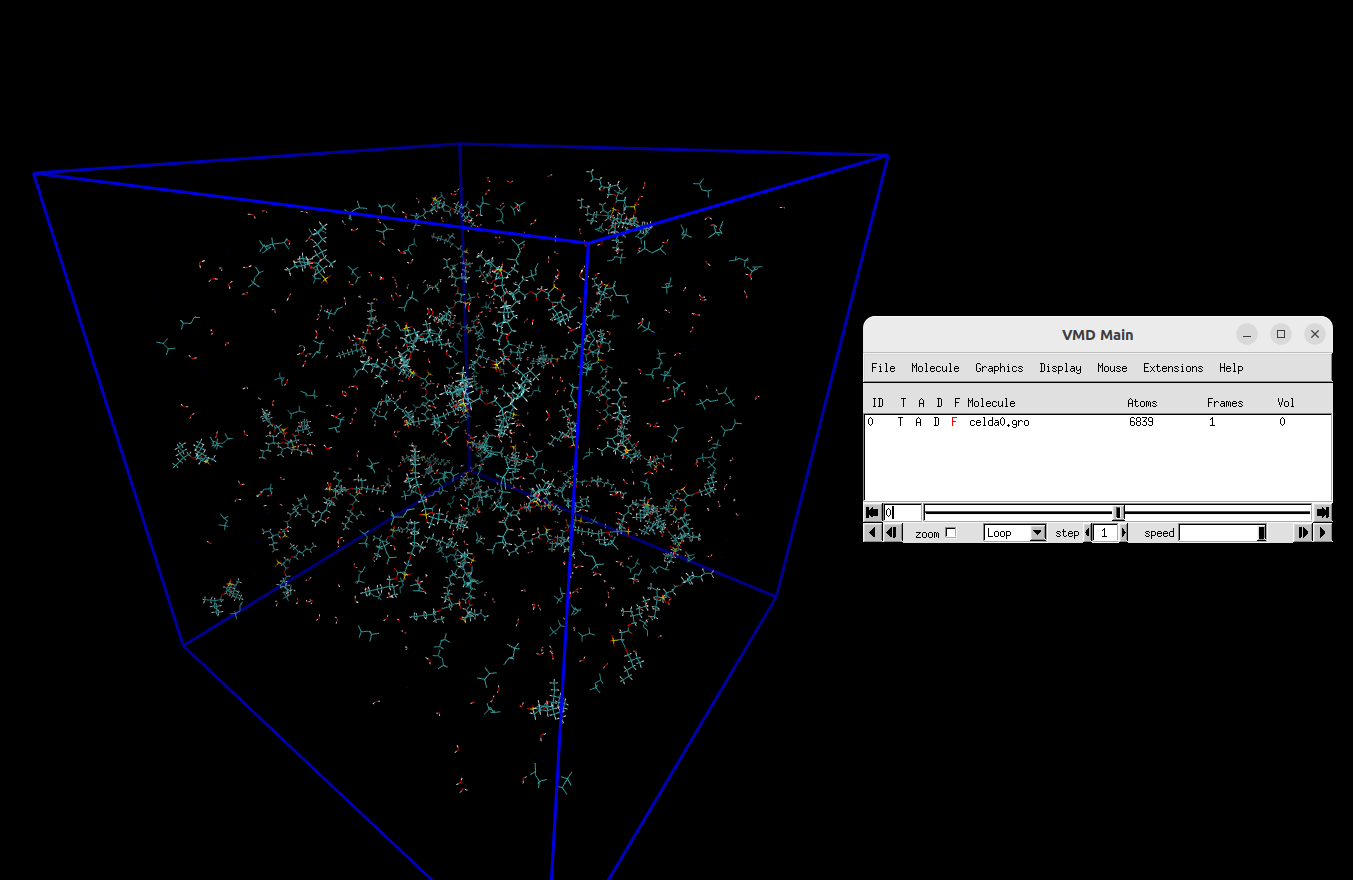

In [1]:
from IPython.display import Image
Image(filename="../imgs/celda0_RM_62.png")

The next step—assuming that the clusters have already formed—is to reposition the main cluster at the center of the simulation cell. This is necessary because, as observed with the RMs used in the article, they tended to remain adhered to the edges of the simulation box during the run. As a result, the configurations became unsuitable for analysis without additional processing. This issue stems from the effects of periodic boundary conditions.

After considerable time and experimentation with various methods (including k-means clustering), a reliable solution was identified using the following GROMACS commands.

### GROMACS Command Explanation – Centering and Fixing a Cluster

These commands are used to process a molecular dynamics trajectory so that a self-assembled cluster (like a reverse micelle) is correctly positioned and visualized. Each step addresses a specific issue caused by periodic boundary conditions (PBCs).


In [ ]:
# gmx trjconv -f ../traj.xtc -skip 10 -o traj10skip.xtc
# gmx trjconv -f traj10skip.xtc -o pbcRes.gro -pbc res
# gmx trjconv -f pbcRes.gro -o pbcResCluster.gro -pbc cluster
# gmx trjconv -f pbcResCluster.gro -o pbcResClusterC.gro -center 

#### 1. **Skip frames to reduce file size and improve speed**

```bash
gmx trjconv -f ../traj.xtc -skip 10 -o traj10skip.xtc

This command reads the original trajectory (`traj.xtc`) and creates a new trajectory (`traj10skip.xtc`) by saving only every 10th frame. Reduces the number of frames to make further processing faster and more manageable.


#### **2. Remove molecules broken by PBC (reconstruct whole molecules)**

```bash
gmx trjconv -f traj10skip.xtc -o pbcRes.gro -pbc res

This fixes molecules that appear split across box boundaries due to periodic images. Ensures each molecule is whole before clustering.

#### **3. Rebuild the main cluster together in one place**

```bash
gmx trjconv -f pbcRes.gro -o pbcResCluster.gro -pbc cluster


This command identifies the largest cluster and puts it back together, even if it was fragmented across the periodic box.
Without this, your cluster may appear as disconnected parts.

#### **4. Center the cluster in the simulation box**

```bash
gmx trjconv -f pbcResCluster.gro -o pbcResClusterC.gro -center


This recenters the system so that the cluster is located in the middle of the simulation cell.
Helps with visualization and makes further analysis easier by keeping the structure in a consistent location.

### 📂 Downloadable Simulation Data

Simulation results for systems containing 23 and 39 AOT molecules—used in the published article—are available for download. These datasets can be used to test the reconstruction of AOT aggregates, particularly in addressing issues caused by periodic boundary conditions.